# Milestone 1 — Kaggle edition

### Add these datasets (Notebook → Add data)
1. **[Formula 1 World Championship 1950-2020](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020)** (required)
2. **`f1-podium-src.zip`** — run `bash scripts/package_kaggle_bundle.sh` locally, upload zip as a new Kaggle dataset named e.g. `f1-podium-src`

### Settings
- Turn **Internet ON** (gear icon) for `pip install shap lime`.

### After Run All
Download outputs from the **Output** tab (`figures/`, `processed/*.csv`).


In [ ]:
# Kaggle environment setup
import os
import sys
import zipfile
from pathlib import Path

WORK = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

for zpath in Path("/kaggle/input").rglob("f1-podium-src.zip") if Path("/kaggle/input").exists() else []:
    with zipfile.ZipFile(zpath) as zf:
        zf.extractall(WORK)
    print("Extracted", zpath)

ROOT = WORK if (WORK / "src").exists() else Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

if Path("/kaggle/working").exists():
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn", "shap", "lime"], check=False)

from src.config import DATA_RAW
print("Project root:", ROOT)
print("CSV folder:", DATA_RAW, "| OK:", (DATA_RAW / "results.csv").exists())


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.audit import audit_foreign_keys, audit_primary_keys
from src.cleaning import build_base_results_table
from src.config import DATA_PROCESSED, FIGURES_DIR
from src.de_analysis import (
    question1_front_row_podium_by_circuit,
    question2_home_podium_controlled_grid,
    question3_mechanical_retirement_by_constructor,
)
from src.experiments import (
    ablation_table,
    imputation_strategy_experiment,
    indy_500_exclusion_experiment,
    preprocessing_order_experiments,
)
from src.features import build_modeling_table
from src.inference import predict_podium
from src.io import load_raw_tables, missing_tables, save_processed
from src.splits import temporal_split
from src.status_mapping import build_status_mapping
from src.train import (
    TARGET,
    collect_ffnn_metrics,
    collect_sklearn_metrics,
    feature_columns,
    train_logistic_regression,
    train_random_forest,
    train_shallow_ffnn,
    pick_threshold_on_val,
)
from src.xai import permutation_importance_table

sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)


## 0. Load data

In [2]:
missing = missing_tables()
if missing:
    raise FileNotFoundError(
        "Place Kaggle CSV files in data/raw. Missing: " + ", ".join(missing)
    )

tables = load_raw_tables()
list(tables.keys())


['circuits',
 'constructors',
 'constructor_results',
 'constructor_standings',
 'drivers',
 'driver_standings',
 'races',
 'results',
 'qualifying',
 'lap_times',
 'pit_stops',
 'sprint_results',
 'seasons',
 'status']

## 1. EDA (before cleaning)

We inspect raw shape, target-related columns, and **qualifying coverage by season** (historical drift motivates median imputation and lagged grid/qualifying features).


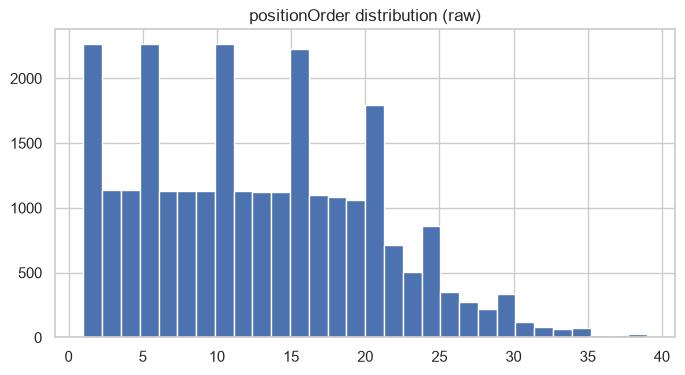

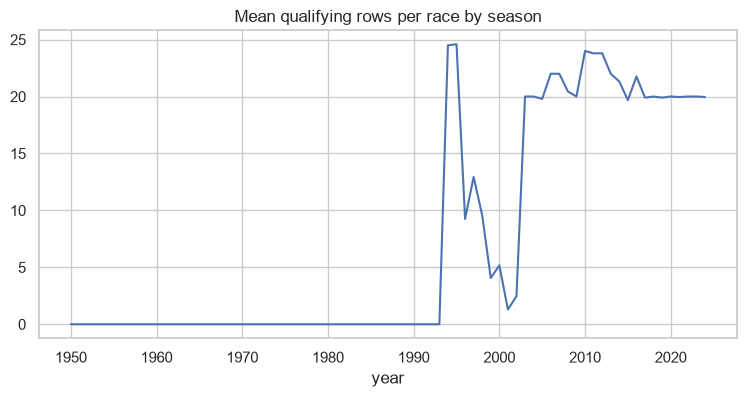

In [3]:
results_raw = tables["results"]
fig, ax = plt.subplots(figsize=(8, 4))
results_raw["positionOrder"].hist(bins=30, ax=ax)
ax.set_title("positionOrder distribution (raw)")
plt.savefig(FIGURES_DIR / "eda_position_order_raw.png", bbox_inches="tight")
plt.show()

qual = tables["qualifying"]
coverage = qual.groupby("raceId").size().rename("rows")
races = tables["races"][["raceId", "year"]]
cov = races.merge(coverage, on="raceId", how="left").fillna(0)
cov_by_year = cov.groupby("year")["rows"].mean()
cov_by_year.plot(figsize=(9, 4), title="Mean qualifying rows per race by season")
plt.savefig(FIGURES_DIR / "eda_qualifying_coverage_by_year.png", bbox_inches="tight")
plt.show()


## 2. Auditing keys & cleaning

**Sentinels:** CSV `\N` parsed as missing via `na_values` in `src/io.py`.

**Grain:** enforce one row per (`raceId`, `driverId`). Early-era **shared drives** create duplicates; we keep the row with the **best `positionOrder`** (lowest value) and document dropped rows in `duplicate_audit`.

**Indianapolis 500 (1950–1960):** excluded from the modeling base (optional sensitivity experiment in §7) because it is not comparable to road-course F1.

**Immutability:** raw files in `data/raw/` are never overwritten; cleaning writes to `data/processed/`.


In [4]:
pk = pd.DataFrame([r.__dict__ for r in audit_primary_keys(tables)])
fk = pd.DataFrame([r.__dict__ for r in audit_foreign_keys(tables)])
display(pk)
display(fk)

base, duplicate_audit = build_base_results_table(
    tables,
    exclude_indy=True,
    dedupe_policy="best_position_order",
)
print("Duplicate (raceId, driverId) rows before policy:", len(duplicate_audit))
assert base.duplicated(["raceId", "driverId"]).sum() == 0
save_processed(base, "base_results")


,table,key_cols,duplicate_rows,null_key_rows
0,circuits,[circuitId],0,0
1,constructors,[constructorId],0,0
2,drivers,[driverId],0,0
3,races,[raceId],0,0
4,results,[resultId],0,0
5,status,[statusId],0,0
6,seasons,[year],0,0


,child_table,child_col,parent_table,parent_col,orphan_rows
0,results,raceId,races,raceId,0
1,results,driverId,drivers,driverId,0
2,results,constructorId,constructors,constructorId,0
3,results,statusId,status,statusId,0
4,races,circuitId,circuits,circuitId,0
5,qualifying,raceId,races,raceId,0
6,driver_standings,raceId,races,raceId,0
7,constructor_standings,raceId,races,raceId,0


Duplicate (raceId, driverId) rows before policy: 131


PosixPath('/home/youssef/Documents/Programming/f1-podium-prediction/data/processed/base_results.parquet')

## 3. EDA (after cleaning)

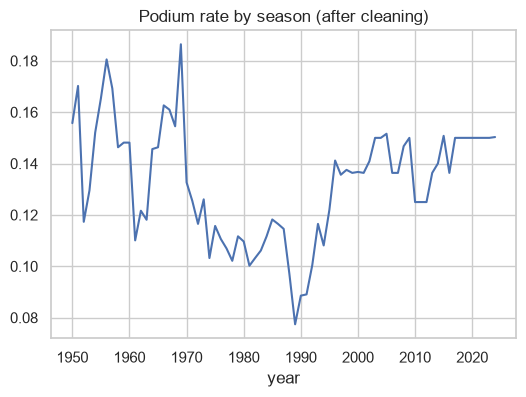

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
base.groupby("year")["podium"].mean().plot(ax=ax)
ax.set_title("Podium rate by season (after cleaning)")
plt.savefig(FIGURES_DIR / "eda_podium_rate_by_year.png", bbox_inches="tight")
plt.show()


## 4. Data-engineering questions

**Q1** uses **grid positions 1–2** (front row after penalties), not qualifying position alone. Era split at **2014** (hybrid rules).

**Q2** compares home vs away podiums within **grid bins** so we do not confound home advantage with better qualifying.

**Q3** mechanical retirements use an explicit **status → category** map (`src/status_mapping.py`); only `category == mechanical` counts, excluding crashes/driver errors/regulatory DNFs.


category
accident_or_driver    16
finished              34
mechanical            45
other_dnf             37
regulatory             7
Name: count, dtype: int64

,circuitId,era,front_row_starts,podiums,podium_rate,name,country
100,80,from_2014,4,4,1.000000,Las Vegas Strip Street Circuit,United States
96,76,from_2014,2,2,1.000000,Autodromo Internazionale del Mugello,Italy
85,65,pre_2014,2,2,1.000000,Pescara Circuit,Italy
89,69,pre_2014,4,4,1.000000,Circuit of the Americas,USA
48,31,pre_2014,2,2,1.000000,Donington Park,UK
84,64,pre_2014,2,2,1.000000,Ain Diab,Morocco
95,75,from_2014,4,4,1.000000,Autódromo Internacional do Algarve,Portugal
99,79,from_2014,6,6,1.000000,Miami International Autodrome,USA
39,22,from_2014,18,16,0.888889,Suzuka Circuit,Japan
97,77,from_2014,8,7,0.875000,Jeddah Corniche Circuit,Saudi Arabia


<Figure size 1000x500 with 0 Axes>

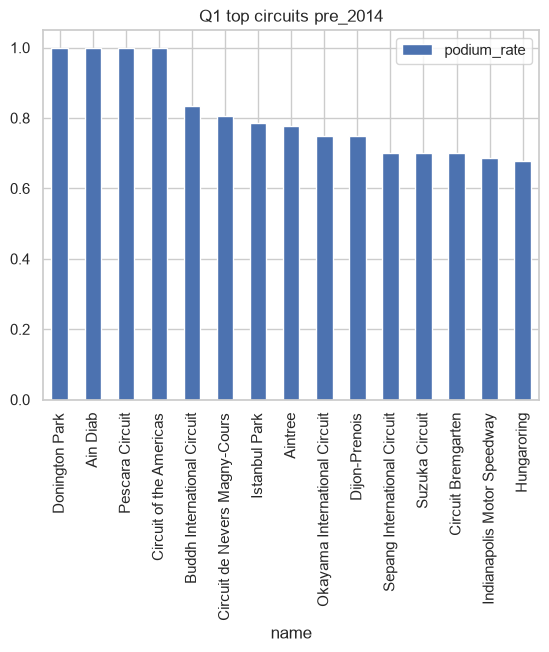

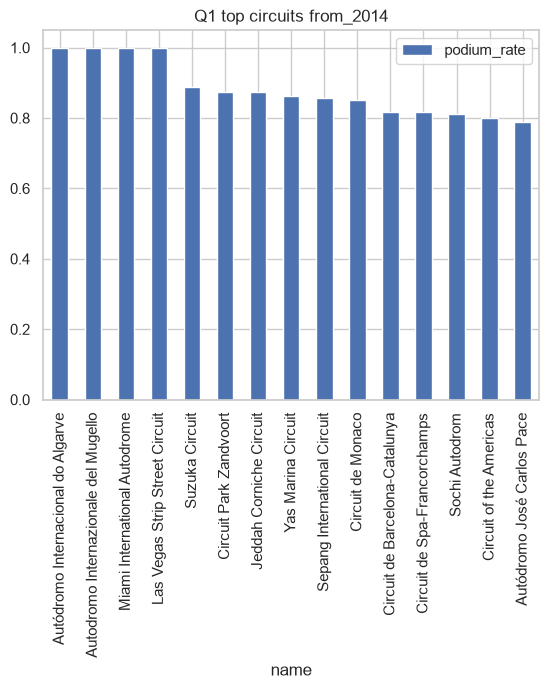

,grid_bin,home_race,starts,podiums,podium_rate
0,"(0, 5]",0,5561,2521,0.453336
1,"(5, 10]",0,5568,618,0.110991
2,"(10, 15]",0,5550,165,0.029730
3,"(15, 25]",0,7656,53,0.006923


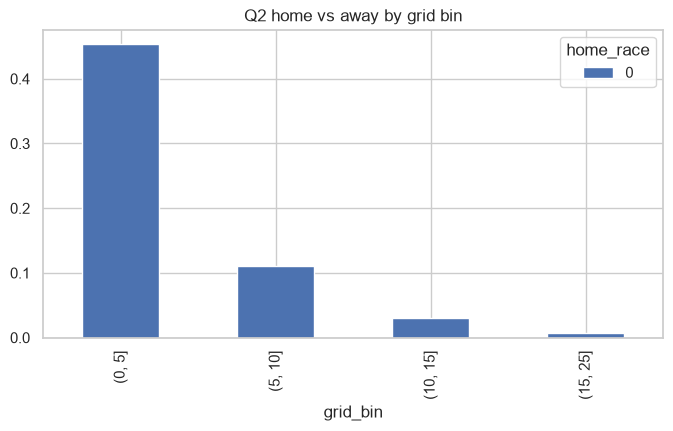

,constructorId,era,starts,mechanical_retirements,mech_rate,name
20,207,2014_2021,34,11,0.323529,Caterham
21,208,2014_2021,76,15,0.197368,Lotus F1
5,5,2014_2021,238,37,0.155462,Toro Rosso
4,4,2014_2021,199,30,0.150754,Renault
0,1,2014_2021,320,47,0.146875,McLaren
23,210,2014_2021,240,29,0.120833,Haas F1 Team
11,15,2014_2021,199,24,0.120603,Sauber
30,215,2022_plus,48,5,0.104167,RB F1 Team
29,214,2022_plus,131,13,0.099237,Alpine F1 Team
19,206,2014_2021,31,3,0.096774,Marussia


In [6]:
status_map = build_status_mapping(tables["status"])
status_map.to_csv(DATA_PROCESSED / "status_category_mapping.csv", index=False)
display(status_map.groupby("category").size().rename("count"))

q1 = question1_front_row_podium_by_circuit(base, tables["circuits"])
q1_top = q1.sort_values("podium_rate", ascending=False).groupby("era").head(10)
display(q1_top)

plt.figure(figsize=(10, 5))
for era, g in q1.groupby("era"):
    g.nlargest(15, "podium_rate").plot(x="name", y="podium_rate", kind="bar", title=f"Q1 top circuits {era}")
plt.savefig(FIGURES_DIR / "de_q1_front_row_podium.png", bbox_inches="tight")
plt.show()

q2 = question2_home_podium_controlled_grid(base, tables["drivers"], tables["circuits"])
display(q2)
q2.pivot(index="grid_bin", columns="home_race", values="podium_rate").plot(
    kind="bar", figsize=(8, 4), title="Q2 home vs away by grid bin"
)
plt.savefig(FIGURES_DIR / "de_q2_home_advantage.png", bbox_inches="tight")
plt.show()

q3 = question3_mechanical_retirement_by_constructor(base, tables["status"], tables["constructors"])
display(q3.sort_values("mech_rate", ascending=False).groupby("era").head(10))


## 5. Feature engineering (leakage-safe)

| Feature group | Valid at cutoff because |
|---------------|-------------------------|
| `grid`, qualifying times/position | Set after qualifying, before race |
| `*_before` standings | Shifted to championship state **entering** this race |
| `podium_rate_prev` | Rolling podiums in **prior** races only |

Target `podium` is derived from `positionOrder` but used only as the label, never as an input.


In [7]:
model_df = build_modeling_table(tables, base)
save_processed(model_df, "modeling_table")
model_df.head()


,raceId,driverId,constructorId,circuitId,year,grid,quali_position,q1_sec,q2_sec,q3_sec,points_before,position_before,constructor_points_before,constructor_position_before,podium_rate_prev,podium
0,1.0,1.0,1.0,1.0,2009.0,18.0,15.0,86.454,NaN,NaN,NaN,NaN,NaN,NaN,0.4,0.0
1,1.0,2.0,2.0,1.0,2009.0,9.0,11.0,85.827,85.504,NaN,60.0,6.0,135.0,3.0,0.0,0.0
2,1.0,3.0,3.0,1.0,2009.0,5.0,5.0,85.846,85.123,86.973,17.0,13.0,26.0,8.0,0.2,0.0
3,1.0,4.0,4.0,1.0,2009.0,10.0,12.0,86.026,85.605,NaN,61.0,5.0,80.0,4.0,0.6,0.0
4,1.0,5.0,1.0,1.0,2009.0,12.0,14.0,86.184,85.726,NaN,NaN,NaN,NaN,NaN,0.2,0.0


## 6. Train / validation / test split

**Temporal split** (no random shuffle — avoids future seasons leaking into training):
- Train: seasons **≤ 2019**
- Validation: **2020–2021** (COVID / format change stress-test)
- Test: **≥ 2022** (ground-effect era, held out until final evaluation)


In [8]:
train_df, val_df, test_df = temporal_split(model_df)
print("rows:", len(train_df), len(val_df), len(test_df))
print("podium rate %:", train_df[TARGET].mean() * 100, val_df[TARGET].mean() * 100, test_df[TARGET].mean() * 100)


rows: 24148 780 1359
podium rate %: 12.580752029153553 15.0 15.011037527593817


## 7. Preprocessing experiments (≥2)

1. **Pipeline order:** median impute → scale vs scale → impute (numeric block).
2. **Imputation statistic:** median vs mean.
3. **Indy 500 policy:** exclude vs include championship rounds.

We report validation **PR-AUC** for each variant (primary metric).


In [9]:
prep_order = preprocessing_order_experiments(train_df, val_df)
prep_impute = imputation_strategy_experiment(train_df, val_df)
prep_indy = indy_500_exclusion_experiment(tables)
display(prep_order)
display(prep_impute)
display(prep_indy)


,preprocessing_order,pr_auc_val
0,impute_then_scale,0.706703
1,scale_then_impute,0.706573


,imputation_strategy,pr_auc_val
0,median,0.706703
1,mean,0.709711


,indy_policy,n_rows,pr_auc_val,pr_auc_test
0,exclude_indy_500,26287,0.706703,0.669177
1,include_indy_500,26668,0.707620,0.665570


## 8. Modeling (≥3 attempts)

1. **Baseline:** logistic regression (interpretable, strong with grid signal).
2. **Non-linear:** random forest (200 trees, class weights).
3. **Shallow FFNN:** 64 → 32 units, dropout 0.2 (Keras).

Threshold for F1: maximized on **validation** F1 per model.


In [10]:
feats = feature_columns(train_df)
splits = {
    "train": (train_df[feats], train_df[TARGET]),
    "val": (val_df[feats], val_df[TARGET]),
    "test": (test_df[feats], test_df[TARGET]),
}

lr, lr_thr = train_logistic_regression(*splits["train"], *splits["val"])
rf = train_random_forest(*splits["train"])
rf_thr = pick_threshold_on_val(splits["val"][1], rf.predict_proba(splits["val"][0])[:, 1])

metrics = collect_sklearn_metrics("logistic_regression", lr, splits, lr_thr)
metrics += collect_sklearn_metrics("random_forest", rf, splits, rf_thr)

try:
    nn, nn_prep, nn_thr = train_shallow_ffnn(*splits["train"], *splits["val"])
    metrics += collect_ffnn_metrics("shallow_ffnn", nn, nn_prep, splits, nn_thr)
except Exception as e:
    print("FFNN skipped:", e)

metrics_df = pd.DataFrame([m.__dict__ for m in metrics])
metrics_df.to_csv(DATA_PROCESSED / "model_metrics.csv", index=False)
display(metrics_df.pivot_table(index="model", columns="split", values=["roc_auc", "pr_auc", "f1"]))


I0000 00:00:1791551093.381976  110983 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791551093.382442  110983 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791551093.419627  110983 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791551094.304642  110983 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791551094.304922  110983 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1791551094.552292  110983 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1791551094.552526  111516 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1791551094.571532  110983 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries menti

f1                        pr_auc            \
split                    test     train       val      test     train   
model                                                                   
logistic_regression  0.640351  0.555131  0.691358  0.669177  0.545584   
random_forest        0.629723  0.987803  0.690909  0.667523  0.998271   
shallow_ffnn         0.651376  0.569825  0.716157  0.666446  0.583159   

                                roc_auc                      
split                     val      test     train       val  
model                                                        
logistic_regression  0.706703  0.925677  0.893458  0.919674  
random_forest        0.708889  0.926146  0.999799  0.920105  
shallow_ffnn         0.735924  0.923186  0.905844  0.913125

## 9. Feature-group ablation

In [11]:
abl = ablation_table(train_df, val_df, test_df)
abl.to_csv(DATA_PROCESSED / "feature_ablation.csv", index=False)
display(abl)


,feature_group_removed,pr_auc_val,pr_auc_test
0,none,0.706703,0.669177
1,grid,0.683260,0.643773
2,qualifying,0.701430,0.650583
3,standings,0.701183,0.656472
4,form,0.711875,0.650220


## 10. Explainability (XAI)

- **Global:** permutation importance + SHAP beeswarm (validation sample).
- **Local:** LIME for one validation row.

**Causal disclaimer:** these tools describe what the model relied on for a prediction, not what *causes* a podium in the real world.


,feature,importance_mean,importance_std
9,podium_rate_prev,0.023333,0.006557
5,points_before,0.005641,0.005991
7,constructor_points_before,0.005385,0.003571
3,q2_sec,0.004872,0.001256
4,q3_sec,0.001282,0.001147
2,q1_sec,0.000769,0.000628
0,grid,-0.000769,0.010683
6,position_before,-0.005385,0.004005
1,quali_position,-0.014615,0.005936
8,constructor_position_before,-0.014872,0.011767


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


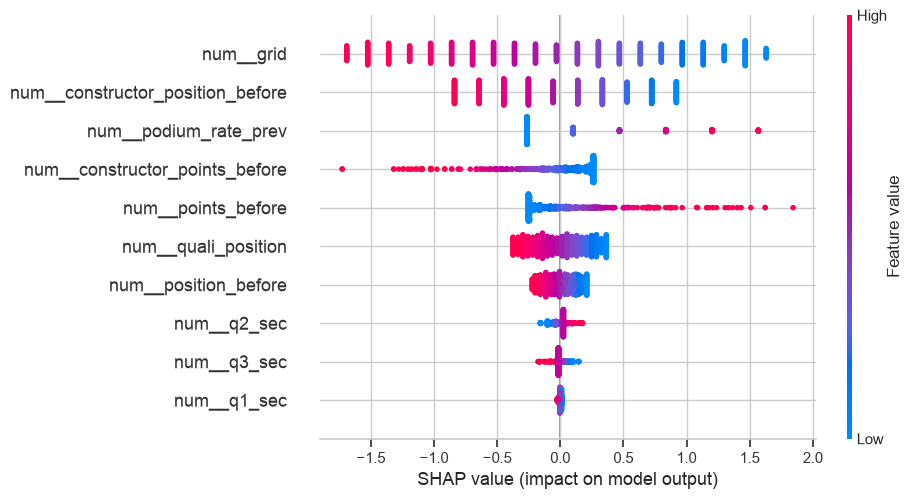

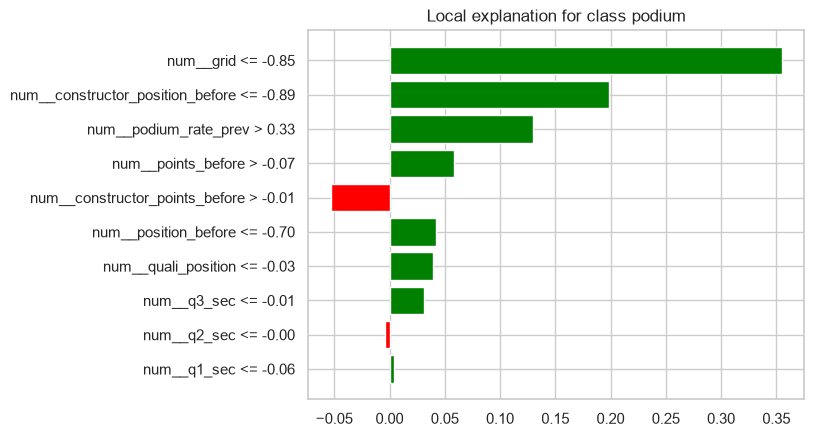

In [12]:
imp = permutation_importance_table(lr, splits["val"][0], splits["val"][1])
display(imp.head(15))

try:
    from src.xai import shap_summary
    import shap

    shap_values = shap_summary(lr, splits["val"][0].sample(min(500, len(val_df)), random_state=42))
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.savefig(FIGURES_DIR / "xai_shap_beeswarm.png", bbox_inches="tight")
    plt.show()
except Exception as e:
    print("SHAP skipped:", e)

try:
    from src.xai import lime_explain_row

    row = splits["val"][0].iloc[[0]]
    exp = lime_explain_row(lr, row, splits["train"][0].sample(min(2000, len(train_df)), random_state=0))
    exp.as_pyplot_figure()
    plt.savefig(FIGURES_DIR / "xai_lime_row0.png", bbox_inches="tight")
    plt.show()
except Exception as e:
    print("LIME skipped:", e)


## 11. Inference function demo

In [13]:
complete = splits["val"][0].iloc[0].to_dict()
partial = {feats[0]: complete[feats[0]]}
print("Complete row:", predict_podium(lr, complete, threshold=lr_thr, feature_names=feats))
print("Partial row:", predict_podium(lr, partial, threshold=lr_thr, feature_names=feats))


Complete row: {'podium_probability': 0.9421996153337767, 'podium_prediction': 1, 'threshold': 0.7877621330739185}
Partial row: {'podium_probability': 0.40865962640627074, 'podium_prediction': 0, 'threshold': 0.7877621330739185}


## 12. Known limitations

- Qualifying features are sparse before the mid-1990s; grid and standings partially substitute.
- Constructor renames break historical "team form" continuity (`constructorId` resets).
- Sprint weekends (2021+) introduce judgment calls; we did not add sprint results as features in this baseline.
- Class imbalance persists; PR-AUC and calibrated thresholds matter more than raw accuracy.
